### Load the dataset and extract the arrays

In [3]:
import numpy as np

# Load the .npz dataset
data = np.load('../data/raw/Dental-Panaromic-Autoencoder.npz')

# Extract the arrays
x_train = data['x_train']
y_train = data['y_train']
x_test = data['x_test']
y_test = data['y_test']

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (92, 256, 256, 3)
y_train shape: (92,)
x_test shape: (24, 256, 256, 3)
y_test shape: (24,)


#### Create a noisy version of the dataset

In [4]:
import tensorflow as tf

noise_factor = 0.2

x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

print(f"x_train_noisy shape: {x_train_noisy.shape}")
print(f"x_test_noisy shape: {x_test_noisy.shape}")

x_train_noisy shape: (92, 256, 256, 3)
x_test_noisy shape: (24, 256, 256, 3)


#### Plot first 5 images from original and noisy datasets

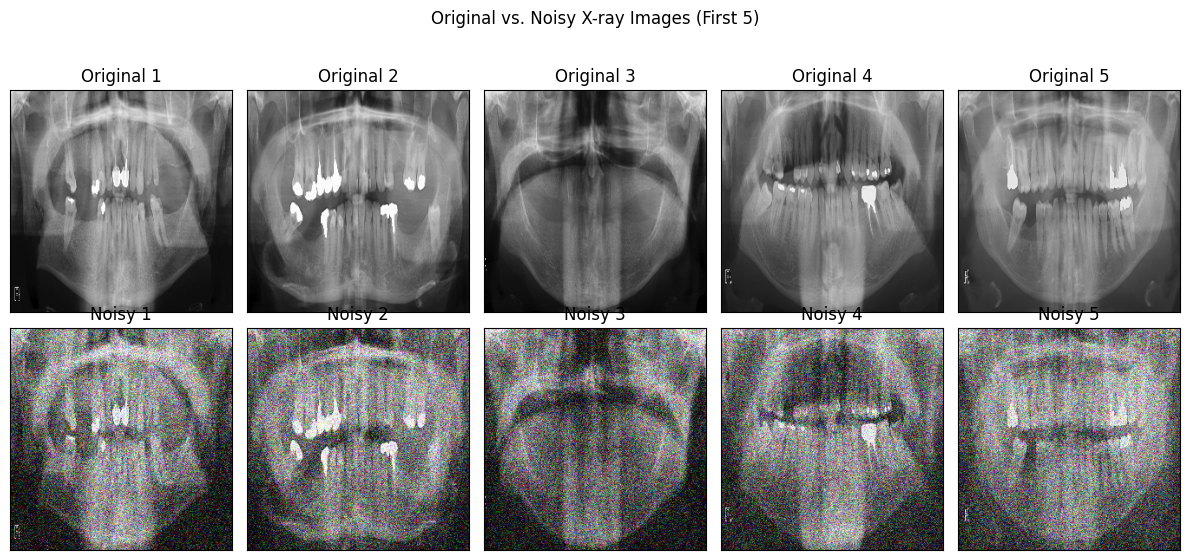

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i in range(5):
    # Original images
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(f"Original {i+1}")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Noisy images
    ax = plt.subplot(2, 5, i + 1 + 5)
    plt.imshow(x_train_noisy[i])
    plt.title(f"Noisy {i+1}")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.suptitle('Original vs. Noisy X-ray Images (First 5)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Denoising Autoencoder Model Definition

In [6]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

class Denoise(Model):
    def __init__(self):
        super(Denoise, self).__init__()
        # Encoder
        self.encoder = tf.keras.Sequential([
            Input(shape=(256, 256, 3)),
            Conv2D(64, (3, 3), activation='relu', padding='same', strides=2),
            Conv2D(32, (3, 3), activation='relu', padding='same', strides=2)
        ])

        # Decoder
        self.decoder = tf.keras.Sequential([
            Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2),
            Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2),
            Conv2D(3, (3, 3), activation='sigmoid', padding='same')
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

### Initialize, Compile, and Train the Autoencoder

In [7]:
# Initialize the autoencoder
autoencoder = Denoise()

# Compile the autoencoder
autoencoder.compile(optimizer=Adam(), loss=MeanSquaredError())

# Train the autoencoder
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=50,
    validation_data=(x_test_noisy, x_test),
    batch_size=32 # Added a batch_size for better training control
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - loss: 0.0530 - val_loss: 0.0519
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 0.0517 - val_loss: 0.0503
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 0.0497 - val_loss: 0.0474
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.0461 - val_loss: 0.0421
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.0396 - val_loss: 0.0329
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.0290 - val_loss: 0.0199
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.0167 - val_loss: 0.0102
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0088 - val_loss: 0.0081
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0078 - val_loss: 0.0087
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0081 - val_loss: 0.0074
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.0066 - val_loss: 0.0049
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.0048 - val_loss

### Plot Training and Validation Loss

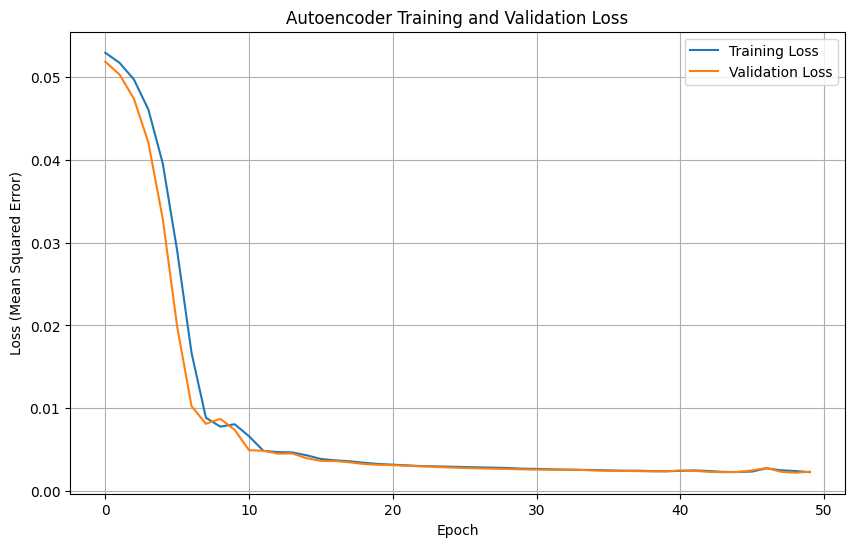

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

### Evaluate the Autoencoder Model

In [9]:
# Pass x_test_noisy into the encoder
encoded_imgs = autoencoder.encoder(x_test_noisy)

# Pass the encoded images into the decoder to get reconstructed (denoised) images
decoded_imgs = autoencoder.decoder(encoded_imgs)

print(f"Shape of encoded images: {encoded_imgs.shape}")
print(f"Shape of decoded images: {decoded_imgs.shape}")

Shape of encoded images: (24, 64, 64, 32)
Shape of decoded images: (24, 256, 256, 1)


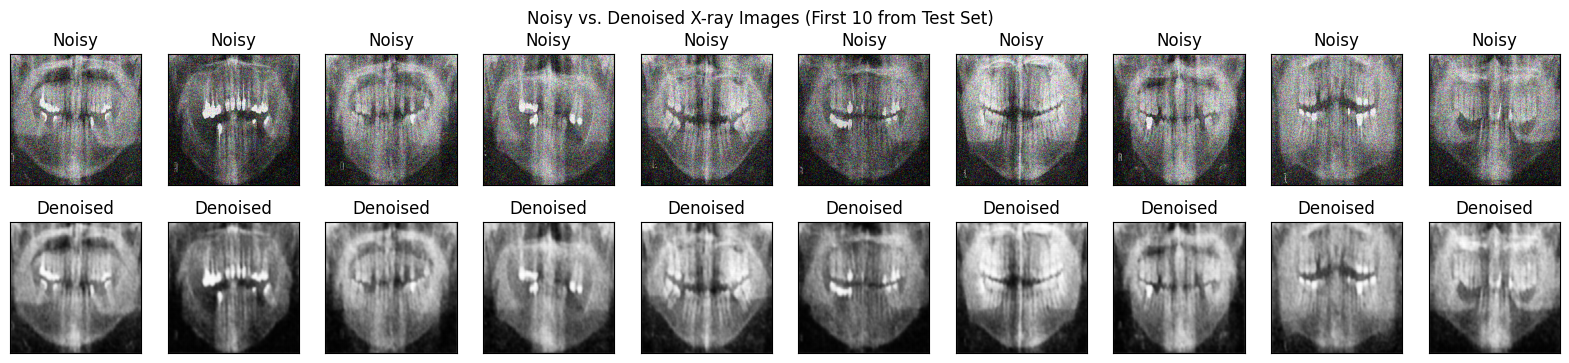

In [10]:
import matplotlib.pyplot as plt

n = 10  # Number of images to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original noisy images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.title("Noisy")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed (denoised) images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.title("Denoised")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.suptitle('Noisy vs. Denoised X-ray Images (First 10 from Test Set)')
plt.show()